In [ ]:
import sys
sys.path.append('../')

import numpy as np
from matplotlib import pyplot as plt
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
import utils_2Q_gate_zp as ut
import qutip as qt
import scqubits as scq
from scipy.ndimage import gaussian_filter
import scipy as sp
from IPython.display import display, Math
from multiprocessing import Pool
from joblib import Parallel, delayed
import pandas as pd

## Population sum/max vs $t_g$

In [ ]:
# drive_phi, drive_theta = True, True
drive_phi, drive_theta = False, True
# drive_phi, drive_theta = True, False
truc1 = 100

folder = '../../data/3ncut_one_zeropi/'
eval0 = 2*np.pi* scq.read(folder + f'zeropi_0_specdata_truc=1000_3ncut.h5').energy_table
n_theta0 = 2*np.pi* scq.read(folder + f'zeropi_0_n_theta_truc=1000_3ncut.h5').matrixelem_table
n_phi0 = 2*np.pi* scq.read(folder + f'zeropi_0_n_phi_truc=1000_3ncut.h5').matrixelem_table
eval0 = eval0 - eval0[0]
if drive_phi:
    w_trans_1 = eval0[9] - eval0[0]
    w_trans_2 = eval0[9] - eval0[2]
    drive_term = n_phi0
if drive_theta:
    w_trans_1 = eval0[7] - eval0[0]
    w_trans_2 = eval0[7] - eval0[2]
    # w_trans_1 = eval0[1] - eval0[0]
    # w_trans_2 = eval0[2] - eval0[1]
    drive_term = n_theta0
if drive_phi and drive_theta:
    w_trans_1 = eval0[9] - eval0[0]
    w_trans_2 = eval0[9] - eval0[2]
    drive_term = 0.976 * n_phi0 + 0.024 * n_theta0

H0 = qt.Qobj(np.diag(eval0))
hilbert_space = np.arange(truc1).tolist()
H0_truc = ut.truncate_2(H0, hilbert_space)
drive_truc = ut.truncate_2(drive_term, hilbert_space)
H_qbt_drive = [H0_truc, [drive_truc, ut.drive_gauss_A],
                        [drive_truc, ut.drive_gauss_B],]
states = [qt.basis(truc1, i) for i in range(truc1)]

f_phi = pd.read_csv('data/data_xgate_phi_3ncut.txt')
f_theta = pd.read_csv('data/data_xgate_theta_3ncut.txt')


In [ ]:
def get_pop(paras):
    [tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = paras
    tlist = np.linspace(0, tg,  num=1* int(tg) )  # total time
    pulse_args = {'drive_amp_A': drive_amp_A ,
            'drive_freq_A': w_trans_1 + 2*np.pi*detune_A, #w_trans_1 + 2*np.pi*detune_A,
            'drive_amp_B': drive_amp_B ,
            'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
            'gate_time': tg,}
    result = qt.mesolve(    H_qbt_drive,    states[0],    tlist,
        e_ops=[state * state.dag() for state in states],
        args=pulse_args,
        options=qt.Options(store_states=True, nsteps=1e4)  )
    
    arr = np.array(result.expect).sum(axis=1)
    top_indices = np.argsort(arr)[-10:]  # Sort and take the last 10 indices    
    top_values = arr[top_indices] # Get the top 10 largest values    
    sorted_order = np.argsort(top_values)[::-1] # Sorting in descending order (optional)
    top_indices = top_indices[sorted_order]
    top_values = np.round(top_values[sorted_order] / np.sum(top_values), 4)    
    population_top_sum = top_values.tolist()
    state_top_sum = np.array(hilbert_space)[top_indices.tolist()].tolist()

    arr = np.array(result.expect).max(axis=1)
    top_indices = np.argsort(arr)[-10:]  # Sort and take the last 10 indices    
    top_values = arr[top_indices] # Get the top 10 largest values    
    sorted_order = np.argsort(top_values)[::-1] # Sorting in descending order (optional)
    top_indices = top_indices[sorted_order]
    top_values = np.round(top_values[sorted_order], 4)    
    population_top_max = top_values.tolist()
    state_top_max = np.array(hilbert_space)[top_indices.tolist()].tolist()    
    return population_top_sum, state_top_sum, population_top_max, state_top_max

n_job = 100
f_phi = pd.read_csv('data/data_xgate_phi_3ncut.txt')
para = f_phi[['tg', 'drive_amp_1', 'drive_amp_2', 'detune_1', 'detune_2']].to_numpy()#[::1,:]
result = Parallel(n_jobs=n_job)(delayed(get_pop)(args) for args in para)
# np.savez('population_sum_max_phi.npz', array1=result)


In [ ]:
f_phi = pd.read_csv('data/data_xgate_theta_3ncut.txt')
para = f_phi[['tg', 'drive_amp_1', 'drive_amp_2', 'detune_1', 'detune_2']].to_numpy()#[::1,:]
result = Parallel(n_jobs=n_job)(delayed(get_pop)(args) for args in para)
# np.savez('population_sum_max_theta.npz', array1=result)

In [ ]:
data = np.load('population_sum_max.npz')
phi = data['phi']
theta = data['theta']
print(np.shape(phi), np.shape(theta))  

(19, 4, 10) (18, 4, 10)


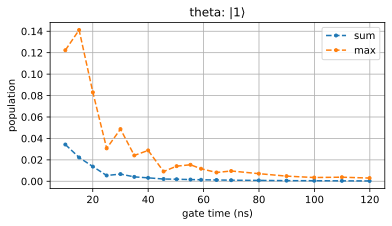

In [ ]:
state = 1
idx_sum = []
idx_max = []
p_sum = []
p_max = []
for i in range(len(theta)):
    idx_sum.append(np.where(np.array(theta[i][1]) == state)[0][0])
    idx_max.append(np.where(np.array(theta[i][3]) == state)[0][0])
    p_sum.append(theta[i][0][idx_sum[-1]])
    p_max.append(theta[i][2][idx_max[-1]])
# print(idx_sum, idx_max)
# print(p_sum, '\n', p_max)

tg = f_theta['tg'].to_numpy()
plt.figure(figsize=(6, 3))
plt.plot(tg, p_sum, '.--', label='sum')
plt.plot(tg, p_max, '.--', label='max')
plt.xlabel('gate time (ns)')
plt.ylabel('population')
plt.title(f'theta: |{state}$\\rangle$')
plt.grid()
plt.legend()
# plt.yscale('log')

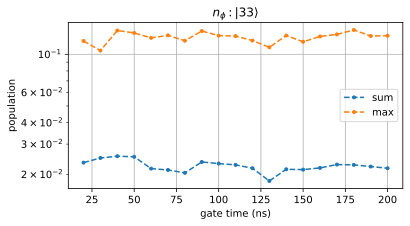

In [ ]:
state = 33
idx_sum = []
idx_max = []
p_sum = []
p_max = []
for i in range(len(phi)):
    idx_sum.append(np.where(np.array(phi[i][1]) == state)[0][0])
    idx_max.append(np.where(np.array(phi[i][3]) == state)[0][0])
    p_sum.append(phi[i][0][idx_sum[-1]])
    p_max.append(phi[i][2][idx_max[-1]])

tg = f_phi['tg'].to_numpy()
plt.figure(figsize=(6, 3))
plt.plot(tg, p_sum, '.--', label='sum')
plt.plot(tg, p_max, '.--', label='max')
plt.xlabel('gate time (ns)')
plt.ylabel('population')
plt.title(f'$n_\phi: |{state}\\rangle$')
plt.grid()
plt.legend()
plt.yscale('log')

In [ ]:
i = -10
print(phi[i][0])  # population_top_sum
print(phi[i][1])  # state_top_sum
print(phi[i][2])  # population_top_max
print(phi[i][3])  # state_top_max

[0.4529 0.3919 0.043  0.0371 0.0307 0.0227 0.0096 0.0059 0.0031 0.003 ]
[ 2.  0.  9. 19. 10. 33. 47. 37. 15. 57.]
[1.     0.9937 0.2452 0.1681 0.1345 0.1277 0.0576 0.0306 0.0176 0.0173]
[ 0.  2.  9. 19. 10. 33. 47. 37. 42. 23.]


In [ ]:
phi[-1,[1,3]]

array([[ 2.,  0.,  9., 19., 10., 33., 47., 37., 15., 42.],
       [ 0.,  2.,  9., 19., 10., 33., 47., 37., 42., 25.]])

In [ ]:
result[0]

([0.3974,
  0.2984,
  0.0728,
  0.0468,
  0.0438,
  0.0369,
  0.0309,
  0.0304,
  0.0234,
  0.0191],
 [0, 2, 23, 57, 10, 19, 9, 37, 33, 85],
 [1.0, 0.6336, 0.1991, 0.1637, 0.1582, 0.1525, 0.1493, 0.1196, 0.1091, 0.0676],
 [0, 2, 23, 10, 9, 57, 19, 33, 37, 15])

## Population transfer

In [2]:
# drive_phi, drive_theta = True, True
# drive_phi, drive_theta = False, True
drive_phi, drive_theta = True, False
truc1 = 100

folder = '../../data/3ncut_one_zeropi/'
eval0 = 2*np.pi* scq.read(folder + f'zeropi_0_specdata_truc=1000_3ncut.h5').energy_table
n_theta0 = 2*np.pi* scq.read(folder + f'zeropi_0_n_theta_truc=1000_3ncut.h5').matrixelem_table
n_phi0 = 2*np.pi* scq.read(folder + f'zeropi_0_n_phi_truc=1000_3ncut.h5').matrixelem_table
eval0 = eval0 - eval0[0]
if drive_phi:
    w_trans_1 = eval0[9] - eval0[0]
    w_trans_2 = eval0[9] - eval0[2]
    drive_term = n_phi0
if drive_theta:
    w_trans_1 = eval0[7] - eval0[0]
    w_trans_2 = eval0[7] - eval0[2]
    # w_trans_1 = eval0[1] - eval0[0]
    # w_trans_2 = eval0[2] - eval0[1]
    drive_term = n_theta0
if drive_phi and drive_theta:
    w_trans_1 = eval0[9] - eval0[0]
    w_trans_2 = eval0[9] - eval0[2]
    drive_term = 0.976 * n_phi0 + 0.024 * n_theta0

In [3]:
# [tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = [39.991616, 0.105045, 0.028058, 0.002171, 0.003988] # theta state 7
# [tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = [25.020473,0.180208,0.046132,-0.003789,0.001544 ]   # theta state 7
# [tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = [828.759495, 0.013563, 0.034964, -0.003029, -0.003182 ]   # mix state 9
# [tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = [200.005395,0.208582,0.081626,0.335171,0.357777 ]   # phi
[tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = [120.004766,0.209273,0.104767,0.341188,0.360503] # phi
H0 = qt.Qobj(np.diag(eval0))
tlist = np.linspace(0, tg,  num=1* int(tg) )  # total time
pulse_args = {'drive_amp_A': drive_amp_A ,
        'drive_freq_A': w_trans_1 + 2*np.pi*detune_A, #w_trans_1 + 2*np.pi*detune_A,
        'drive_amp_B': drive_amp_B ,
        'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
        'gate_time': tg,}

hilbert_space = np.arange(truc1).tolist()
H0_truc = ut.truncate_2(H0, hilbert_space)
drive_truc = ut.truncate_2(drive_term, hilbert_space)
H_qbt_drive = [H0_truc, [drive_truc, ut.drive_gauss_A],
                        [drive_truc, ut.drive_gauss_B],]
states = [qt.basis(truc1, i) for i in range(truc1)]

In [4]:
result = {}
logi_state = [0, 2]
logi_index = [hilbert_space.index(i) for i in logi_state]
for jdx, state_j in enumerate(logi_index):
    result[jdx] = qt.mesolve(
        H_qbt_drive,
        states[state_j],
        tlist,
        e_ops=[state * state.dag() for state in states],
        args=pulse_args,
        options=qt.Options(store_states=True, nsteps=1e4)  )

In [22]:
arr = np.array(result[0].expect).sum(axis=1)
# Get the indices of the top 10 largest values
top_indices = np.argsort(arr)[-10:]  # Sort and take the last 10 indices
top_indices


array([57, 15, 37, 47, 33, 10, 19,  9,  0,  2])

In [23]:
# Get the top 10 largest values
top_values = arr[top_indices]
# Sorting in descending order (optional)
sorted_order = np.argsort(top_values)[::-1]
top_indices = top_indices[sorted_order]
top_values = np.round(top_values[sorted_order] / np.sum(top_values), 4)
print("\nTop 10 values:", top_values.tolist())
print("State of large population:", np.array(hilbert_space)[top_indices.tolist()])


Top 10 values: [0.4545, 0.3937, 0.0412, 0.0372, 0.031, 0.0217, 0.0093, 0.0061, 0.0029, 0.0024]
State of large population: [ 2  0  9 19 10 33 47 37 15 57]


In [17]:
print(np.shape(result[0].expect))
# print(np.shape(np.array(result[0].expect).sum(axis=0)))
print(np.shape(np.array(result[0].expect).sum(axis=1)))
print(np.shape(np.array(result[0].expect).max(axis=1)))
np.array(result[0].expect).max(axis=1)

(100, 120)
(100,)
(100,)


array([1.00000000e+00, 4.38554035e-28, 9.91788741e-01, 4.16723477e-04,
       5.57809750e-04, 3.13119082e-28, 6.37957413e-28, 1.66654767e-27,
       5.63978737e-04, 2.35823479e-01, 1.58682589e-01, 6.25995517e-04,
       6.36240714e-28, 2.76846099e-27, 2.05878966e-27, 1.44763259e-02,
       3.28199548e-03, 1.59891389e-26, 3.49287927e-04, 1.76237363e-01,
       4.16732650e-04, 3.06819299e-26, 1.41949632e-26, 1.48826595e-02,
       1.57120262e-04, 1.50077938e-02, 1.34920493e-27, 2.49940163e-27,
       8.52610121e-03, 1.28987238e-28, 4.24299775e-27, 4.75761190e-03,
       6.15159756e-26, 1.20186972e-01, 2.42815287e-28, 3.48507572e-04,
       1.17604429e-25, 3.47063009e-02, 1.23427526e-25, 9.88343567e-04,
       7.13767143e-03, 7.33786675e-25, 1.71710838e-02, 3.27884142e-04,
       1.22313812e-27, 2.03536504e-26, 1.93597173e-03, 5.60911057e-02,
       2.55105705e-27, 1.03445825e-03, 1.74102138e-26, 2.24212990e-03,
       1.09490010e-27, 1.14928766e-03, 5.50154789e-28, 2.66450310e-03,
      

In [16]:
# hspace_select =  [
# ### charge_140
# 0, 2, 3, 4, 8, 9, 10, 11, 15, 16 ,
# 18, 19, 20, 23, 24, 25, 28, 31, 33, 35 ,
# 37, 39, 40, 42, 43, 46, 47, 49, 51, 53 ,
# 55, 56, 57, 60, 62, 64, 66, 67, 69, 70 ,
# 73, 76, 77, 79, 81, 83, 85, 86, 88, 91 ,

# 92, 95, 96, 98, 100, 101, 102, 104, 106, 108 ,
# 110, 112, 113, 116, 118, 120, 121, 123, 126, 128 ,
# 130, 132, 133, 136, 137, 139, 141, 143, 145, 146 ,
# 148, 151, 153, 154, 156, 158, 159, 162, 164, 166 ,
# 167, 169, 170, 173, 174, 176, 179, 181, 183, 185 ,

# 186, 188, 190, 192, 194, 196, 198, 200, 202, 205 ,
# 206, 208, 209, 212, 213, 216, 218, 220, 222, 223 ,
# 226, 227, 229, 230, 232, 234, 237, 239, 241, 242 ,
# 245, 246, 248, 250, 252, 253, 255, 257, 259, 262 ,
# ]
# hspace_full = np.arange(truc1).tolist()
# logi_idx_select = [hspace_select.index(i) for i in logi_state]
# index_select = [hspace_full.index(i) for i in hspace_select]
# len_select = len(hspace_select)
# H0_full = qt.Qobj(np.diag(eval0))

# H0_select = ut.truncate_2( H0_full, index_select)
# drive_select = ut.truncate_2(drive_term, index_select)
# H_drive_select = [H0_select, [drive_select, ut.drive_gauss_A],
#                                 [drive_select, ut.drive_gauss_B],]

# c_op_list = []
# num_cpus = 4
# args = [H_drive_select, w_trans_1, w_trans_2, num_cpus, c_op_list, logi_idx_select]
# args_indep = [tg, drive_amp_A, drive_amp_B, detune_A, detune_B]

# f_ideal = ut.xgate_fidelity_log_noise(args_indep, *args)
# print(f' dim_hspace = {len_select}')
# print(f' f_ideal (log) = {f_ideal}')
# print(f' f_ideal = {1-10**f_ideal}')

In [17]:
# t1_tphi_other_vec = [3, 30, 170] # μs
# hspace_charge_dim = len(hspace_select)
# gamma_new = pd.read_csv('data/data_gamma_phi_truc200.txt')
# f_noise = []
# for t1_tphi_other in t1_tphi_other_vec:
#     gamma_decay_new = gamma_new['t1_50us_49'].to_numpy()
#     gamma_dephase_new = gamma_new['tphi_50us_02'].to_numpy()
#     gamma_decay_new = gamma_decay_new *50 /t1_tphi_other
#     gamma_dephase_new = gamma_dephase_new *50 /t1_tphi_other
#     jump_t1   = []
#     jump_tphi = []
#     for i in range(1,hspace_charge_dim):
#         jump_t1.append( np.sqrt(gamma_decay_new[i]) * qt.basis(hspace_charge_dim,0) * qt.basis(hspace_charge_dim,i).dag() )
#         jump_tphi.append( np.sqrt(2*gamma_dephase_new[i]) * qt.basis(hspace_charge_dim,i).proj() )
#     c_op_list = jump_t1 + jump_tphi
#     args = [H_drive_select, w_trans_1, w_trans_2, num_cpus, c_op_list, logi_idx_select]
#     f_noise.append(ut.xgate_fidelity_log_noise(args_indep, *args))
# f_noise = np.array(f_noise)
# print(f' dim_hspace = {len_select}')
# print(f' f_ideal = {1-10**f_ideal}')
# print(f' f_noise (T={t1_tphi_other_vec}) = {1-10**f_noise}')

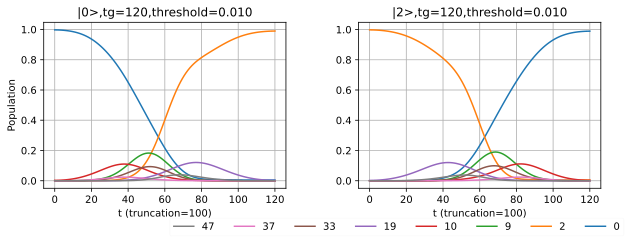

In [5]:
#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
state_phi = [0, 2, 9, 10, 19, 33, 37, 47] # phi
state_phi_theta = [0, 2, 9, 33] # phi
state_theta = [0, 2, 7, 25] # theta
state_interest = state_theta if drive_theta else state_phi
state_interest = state_phi_theta if drive_phi and drive_theta else state_interest
#ax[0].plot(tlist_se, drive)
# fig.suptitle('with drag: fidelity=%.8f'%fidelity_real[0])
plt.subplots_adjust(wspace=0.3, hspace=0.3)
order = ['(a)', '(b)','(c)','(d)']
threshold = 0.01
for jdx, state_j in enumerate(logi_state):
    for state, res in enumerate(result[jdx].expect):
        # if state in state_interest:
        pop = gaussian_filter( np.array(res).flatten(), 6)
        if np.max(pop) > threshold:
            ax[jdx].plot(tlist, pop, label=r"%d"%hilbert_space[state])
        # ax[jdx].plot(tlist_se, np.array(res).flatten(), label=r"%d"%hilbert_space[state])
    # ax[jdx].set_ylim(-0.001,0.12)
    ax[jdx].grid()
    # ax[jdx].legend().get_frame().set_alpha(0.1)
    ax[jdx].set_xlabel(f't (truncation={truc1})')
    # ax[jdx].set_title(f'$n_\\theta$: state 1, fidelity=0.99')
    ax[jdx].set_title('|'+str(state_j)+f'>,tg={tg:.0f},threshold={threshold:.3f}')
    # ax[idx][jdx].text(0.05, 0.93, order[2*idx+jdx], transform=ax[idx][jdx].transAxes,  va='top')
ax[0].set_ylabel('Population')
handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend( handles[::-1],labels[::-1], ncol=8,
            loc='upper left', bbox_to_anchor=(0.5, -0.15)).get_frame().set_alpha(0.1)

In [6]:
ut.top_population(np.array(result[0].expect).sum(axis=1), np.arange(truc1))
ut.top_population(np.array(result[1].expect).sum(axis=1), np.arange(truc1))


Top 10 values: [0.4545, 0.3937, 0.0412, 0.0372, 0.031, 0.0217, 0.0093, 0.0061, 0.0029, 0.0024]
State of large population: [ 2  0  9 19 10 33 47 37 15 57]

Top 10 values: [0.4507, 0.3948, 0.0433, 0.0363, 0.0315, 0.0231, 0.0089, 0.0061, 0.0032, 0.0023]
State of large population: [ 2  0  9 19 10 33 47 37 15 42]


In [20]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

In [ ]:
# 1-np.sum([0.4207, 0.419]) # theta
# 1-np.sum([0.4503, 0.3979, ]) # phi

0.1603

In [ ]:
pop = np.array(result[0].expect)
pop_integral = pop.sum(axis=1)
print(np.shape(pop))
print(np.shape(pop_integral))
# Example NumPy array
arr = pop_integral

# Get the indices of the top 10 largest values
top_indices = np.argsort(arr)[-20:]  # Sort and take the last 10 indices

# Get the top 10 largest values
top_values = arr[top_indices]

# Sorting in descending order (optional)
sorted_order = np.argsort(top_values)[::-1]
top_indices = top_indices[sorted_order]
top_values = top_values[sorted_order]

print("Top 10 values:", top_values.tolist())
print("State of large population:", top_indices.tolist())


(100, 2484)
(100,)
Top 10 values: [1190.550927861234, 1156.830693466407, 130.47165116053213, 4.154723727370572, 0.5595866576824646, 0.4640594697560738, 0.44191688404104734, 0.11260125459929461, 0.07897514816871501, 0.06645414561210271, 0.0502726469630128, 0.03420627389259774, 0.03162684471474558, 0.026383127318220165, 0.024862369102537835, 0.02202404191580761, 0.016787739623942578, 0.013641766895993904, 0.01281914420123477, 0.008039295698775973]
State of large population: [0, 2, 9, 33, 10, 19, 55, 25, 69, 15, 23, 92, 18, 46, 31, 16, 53, 76, 39, 49]


In [ ]:
pop = np.array(result[0].expect)
pop_interest = pop[state_interest, :]
pop_other = np.delete(pop, state_interest, axis=0).sum(axis=0)
pop_save = np.vstack((tlist,pop_interest, pop_other)).T
col_phi = ['tg'] + [f'{i}' for i in state_phi] + ['other']
col_theta = ['tg'] + [f'{i}' for i in state_theta] + ['other']
col_phi_theta = ['tg'] + [f'{i}' for i in state_phi_theta] + ['other']
columns = col_theta if drive_theta else col_phi

df = pd.DataFrame(pop_save, columns=col_phi_theta)
df.to_csv('data/population_phi+theta_825.txt', sep=',', index=False, header=True)

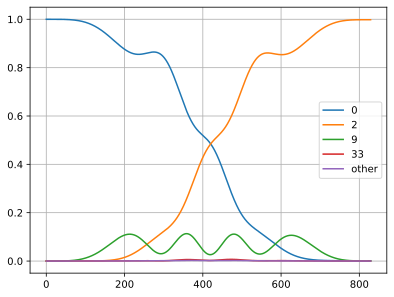

In [ ]:
df_import = pd.read_csv('data/population_phi+theta_825.txt').to_numpy()
for i in np.arange(1, df_import.shape[1]):
    plt.plot(df_import[:,0], gaussian_filter( df_import[:,i], 6), label=col_phi_theta[i] )
plt.legend()
plt.grid()


In [ ]:
# ut.top_population(df_import[:,1:].sum(axis=1), np.arange(truc1))
# ut.top_population(np.array(result[1].expect).sum(axis=1), np.arange(truc1))


Top 10 values: [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
State of large population: [ 5  4  3  1  6  9 43 26 33 58]

Top 10 values: [0.4237, 0.4159, 0.0936, 0.0281, 0.009, 0.0087, 0.0075, 0.0067, 0.0035, 0.0032]
State of large population: [ 2  0  7 25  4  1  5 11  8 18]


In [ ]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

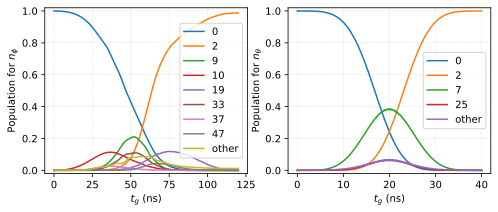

In [ ]:
from scipy.ndimage import gaussian_filter
pop_phi = pd.read_csv('data/population_phi.txt').to_numpy()
pop_theta = pd.read_csv('data/population_theta.txt').to_numpy()

col_phi = ['tg'] + [f'{i}' for i in state_phi] + ['other']
col_theta = ['tg'] + [f'{i}' for i in state_theta] + ['other']

x_size, y_size = 8, 3
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(x_size, y_size))
# plt.subplots_adjust(wspace=0.5)
for i in np.arange(1, pop_phi.shape[1]):
    ax[0].plot( pop_phi[:,0], gaussian_filter( pop_phi[:,i], 3), '-', label=col_phi[i])
for i in np.arange(1, pop_theta.shape[1]):
    ax[1].plot( pop_theta[:,0], gaussian_filter( pop_theta[:,i], 3), '-', label=col_theta[i])
ax[0].set_ylabel(r'Population for $n_\phi$')
ax[1].set_ylabel(r'Population for $n_\theta$')

for i in range(2):
    # ax[i].set_xlim(-25, 25)
    ax[i].set_ylim(-0.02, 1.02)
    ax[i].legend()
    ax[i].grid(linewidth=0.2, linestyle='--')
    ax[i].set_xlabel(r'$t_g$ (ns)')



In [ ]:
=

In [ ]:
#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
#ax[0].plot(tlist_se, drive)
# fig.suptitle('with drag: fidelity=%.8f'%fidelity_real[0])
plt.subplots_adjust(wspace=0.3, hspace=0.3)
order = ['(a)', '(b)','(c)','(d)']
for jdx, state_j in enumerate(logi_state):
    for state, res in enumerate(result[jdx].expect):
        # if state in state_interest:
        ax[jdx].plot(tlist, gaussian_filter( np.array(res).flatten(), 5) , label=r"%d"%hilbert_space[state])
        # ax[jdx].plot(tlist_se, np.array(res).flatten(), label=r"%d"%hilbert_space[state])
    # ax[jdx].set_ylim(-0.001,0.12)
    ax[jdx].grid()
    ax[jdx].set_xlabel(f't (truncation={truc1})')
    ax[jdx].set_title(f'$n_\\theta$: tg={np.round(tg,1)}, fidelity=0.99')
    # ax[jdx].set_title('initial state=|'+str(state_i)+str(state_j)+'>')
    # ax[idx][jdx].text(0.05, 0.93, order[2*idx+jdx], transform=ax[idx][jdx].transAxes,  va='top')
ax[0].set_ylabel('Population')
handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend( handles[::-1],labels[::-1], ncol=8,
            loc='upper center', bbox_to_anchor=(0.5, -0.15)).get_frame().set_alpha(0.1)

#### Pulse

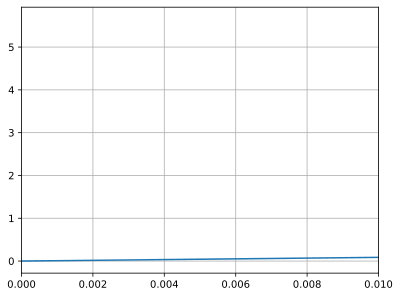

In [ ]:
def drive_gauss_B(t: float, args: dict) -> float:
    """
    Compute the pulse for qubit B.

    Args:
        t (float): Time at which to evaluate the pulse (0 <= t <= gate_time).
        args (dict): Dictionary containing pulse parameters:
            - drive_amp_B (float): Drive amplitude for qubit B.
            - drive_freq_B (float): Drive frequency for qubit B.
            - gate_time (float): Total duration of the gate.

    Returns:
        float: The value of the pulse for qubit B at time `t`.
    """
    A = args.get('drive_amp_B', 0)
    wd = args.get('drive_freq_B', 0)
    tg = args.get('gate_time', 0)
    return A * (np.exp(-8 * t * (t - tg) / tg**2) - 1) * np.cos(wd * t) * (0<=t<=tg)

t_vec = np.linspace(0, 25, 1000)
pulse = [drive_gauss_B(t, {'drive_amp_B': 1, 'drive_freq_B': 1, 'gate_time': 1}) for t in t_vec]

plt.plot(t_vec, pulse)
plt.xlim(0,0.01)
plt.grid()